In [1]:
# Section 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [2]:
# Section 2 - Load the Dataset
df = pd.read_csv('palmtrade_financial.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Shape:", df.shape)
print("\nDate Range:", df['Date'].min(), "to", df['Date'].max())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (300, 14)

Date Range: 2019-01-01 00:00:00 to 2023-12-01 00:00:00

Missing Values:
Date                      0
Year                      0
Month                     0
Month_Name                0
Quarter                   0
Region                    0
Revenue_NGN               0
COGS_NGN                  0
Gross_Profit_NGN          0
Operating_Expenses_NGN    0
Marketing_Spend_NGN       0
Net_Profit_NGN            0
Units_Sold                0
Gross_Margin_Pct          0
dtype: int64

First 5 rows:


,Date,Year,Month,Month_Name,Quarter,Region,Revenue_NGN,COGS_NGN,Gross_Profit_NGN,Operating_Expenses_NGN,Marketing_Spend_NGN,Net_Profit_NGN,Units_Sold,Gross_Margin_Pct
0,2019-01-01,2019,1,Jan,Q1,Lagos,15791187.76,9207680.55,6583507.21,2761285.39,1241913.10,2675555.27,5626,41.69
1,2019-01-01,2019,1,Jan,Q1,Abuja,9132912.31,5325308.03,3807604.27,1597003.20,624249.37,1547420.75,3361,41.69
2,2019-01-01,2019,1,Jan,Q1,Kano,7816365.67,4557643.11,3258722.55,1366788.66,474290.66,1324353.73,2878,41.69
3,2019-01-01,2019,1,Jan,Q1,Port Harcourt,6870745.86,4006261.85,2864484.01,1201435.28,367462.46,1164134.11,2305,41.69
4,2019-01-01,2019,1,Jan,Q1,Ibadan,4895366.05,2854438.02,2040928.03,856015.58,370402.08,829438.71,1852,41.69


In [3]:
# Section 3 - Financial Overview
print("=" * 58)
print("   PALMTRADE NIGERIA LTD — FINANCIAL OVERVIEW")
print("=" * 58)

total_revenue = df['Revenue_NGN'].sum()
total_profit = df['Net_Profit_NGN'].sum()
total_units = df['Units_Sold'].sum()
avg_margin = df['Gross_Margin_Pct'].mean()
best_year = df.groupby('Year')['Revenue_NGN'].sum().idxmax()
best_year_rev = df.groupby('Year')['Revenue_NGN'].sum().max()
worst_year = df.groupby('Year')['Revenue_NGN'].sum().idxmin()

print(f"""
5-YEAR PERFORMANCE (2019-2023)
------------------------------
Total Revenue:        NGN {total_revenue:,.0f}
Total Net Profit:     NGN {total_profit:,.0f}
Total Units Sold:     {total_units:,}
Avg Gross Margin:     {avg_margin:.1f}%

YEAR HIGHLIGHTS
------------------------------
Best Year:            {best_year} (NGN {best_year_rev:,.0f})
Worst Year:           {worst_year} (COVID impact)

REVENUE BY REGION
------------------------------""")
region_rev = df.groupby('Region')['Revenue_NGN'].sum().sort_values(ascending=False)
for region, rev in region_rev.items():
    print(f"{region:<20} NGN {rev:,.0f}")
print("=" * 58)

   PALMTRADE NIGERIA LTD — FINANCIAL OVERVIEW

5-YEAR PERFORMANCE (2019-2023)
------------------------------
Total Revenue:        NGN 5,071,495,811
Total Net Profit:     NGN 796,188,555
Total Units Sold:     1,711,541
Avg Gross Margin:     40.1%

YEAR HIGHLIGHTS
------------------------------
Best Year:            2023 (NGN 1,393,044,791)
Worst Year:           2019 (COVID impact)

REVENUE BY REGION
------------------------------
Lagos                NGN 1,776,147,510
Abuja                NGN 1,012,932,100
Kano                 NGN 921,708,549
Port Harcourt        NGN 756,268,297
Ibadan               NGN 604,439,355


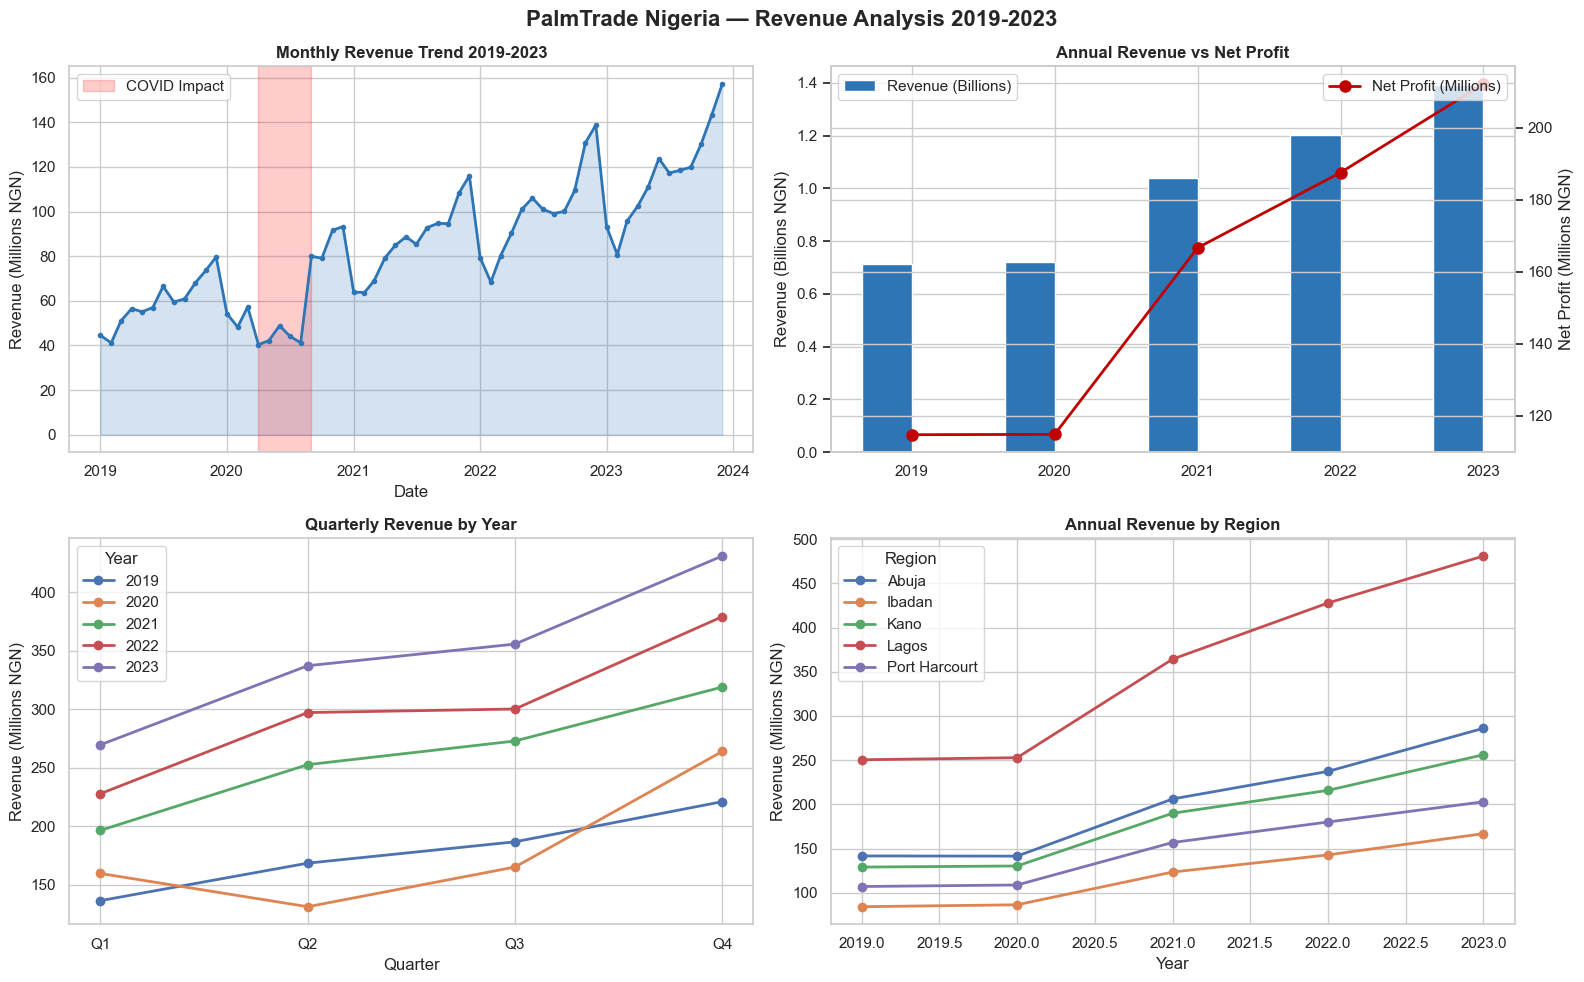

In [4]:
# Section 4 - Revenue Trend Analysis

# Aggregate to monthly totals across all regions
monthly = df.groupby('Date')[['Revenue_NGN', 'Net_Profit_NGN', 
                               'Gross_Profit_NGN']].sum().reset_index()
monthly['Revenue_M'] = (monthly['Revenue_NGN'] / 1_000_000).round(2)
monthly['Profit_M'] = (monthly['Net_Profit_NGN'] / 1_000_000).round(2)
monthly['Gross_M'] = (monthly['Gross_Profit_NGN'] / 1_000_000).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Chart 1 - Monthly Revenue Trend
axes[0,0].plot(monthly['Date'], monthly['Revenue_M'], 
               color='#2E75B6', linewidth=2, marker='o', markersize=3)
axes[0,0].fill_between(monthly['Date'], monthly['Revenue_M'], 
                        alpha=0.2, color='#2E75B6')
axes[0,0].set_title('Monthly Revenue Trend 2019-2023', fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Revenue (Millions NGN)')
axes[0,0].axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2020-08-31'),
                   alpha=0.2, color='red', label='COVID Impact')
axes[0,0].legend()

# Chart 2 - Annual Revenue vs Net Profit
annual = df.groupby('Year')[['Revenue_NGN', 'Net_Profit_NGN']].sum().reset_index()
annual['Revenue_B'] = (annual['Revenue_NGN'] / 1_000_000_000).round(3)
annual['Profit_M'] = (annual['Net_Profit_NGN'] / 1_000_000).round(1)
x = np.arange(len(annual))
width = 0.35
bars1 = axes[0,1].bar(x - width/2, annual['Revenue_B'], width, 
                       label='Revenue (Billions)', color='#2E75B6')
ax2 = axes[0,1].twinx()
ax2.plot(x, annual['Profit_M'], color='#C00000', marker='o', 
         linewidth=2, markersize=8, label='Net Profit (Millions)')
axes[0,1].set_title('Annual Revenue vs Net Profit', fontweight='bold')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(annual['Year'])
axes[0,1].set_ylabel('Revenue (Billions NGN)')
ax2.set_ylabel('Net Profit (Millions NGN)')
axes[0,1].legend(loc='upper left')
ax2.legend(loc='upper right')

# Chart 3 - Revenue by Quarter
quarterly = df.groupby(['Year', 'Quarter'])['Revenue_NGN'].sum().reset_index()
quarterly['Revenue_M'] = (quarterly['Revenue_NGN'] / 1_000_000).round(2)
for year in quarterly['Year'].unique():
    year_data = quarterly[quarterly['Year'] == year]
    axes[1,0].plot(year_data['Quarter'], year_data['Revenue_M'],
                   marker='o', linewidth=2, label=str(year))
axes[1,0].set_title('Quarterly Revenue by Year', fontweight='bold')
axes[1,0].set_xlabel('Quarter')
axes[1,0].set_ylabel('Revenue (Millions NGN)')
axes[1,0].legend(title='Year')

# Chart 4 - Revenue by Region
region_annual = df.groupby(['Year', 'Region'])['Revenue_NGN'].sum().reset_index()
region_annual['Revenue_M'] = (region_annual['Revenue_NGN'] / 1_000_000).round(2)
for region in region_annual['Region'].unique():
    region_data = region_annual[region_annual['Region'] == region]
    axes[1,1].plot(region_data['Year'], region_data['Revenue_M'],
                   marker='o', linewidth=2, label=region)
axes[1,1].set_title('Annual Revenue by Region', fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Revenue (Millions NGN)')
axes[1,1].legend(title='Region')

plt.suptitle('PalmTrade Nigeria — Revenue Analysis 2019-2023',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

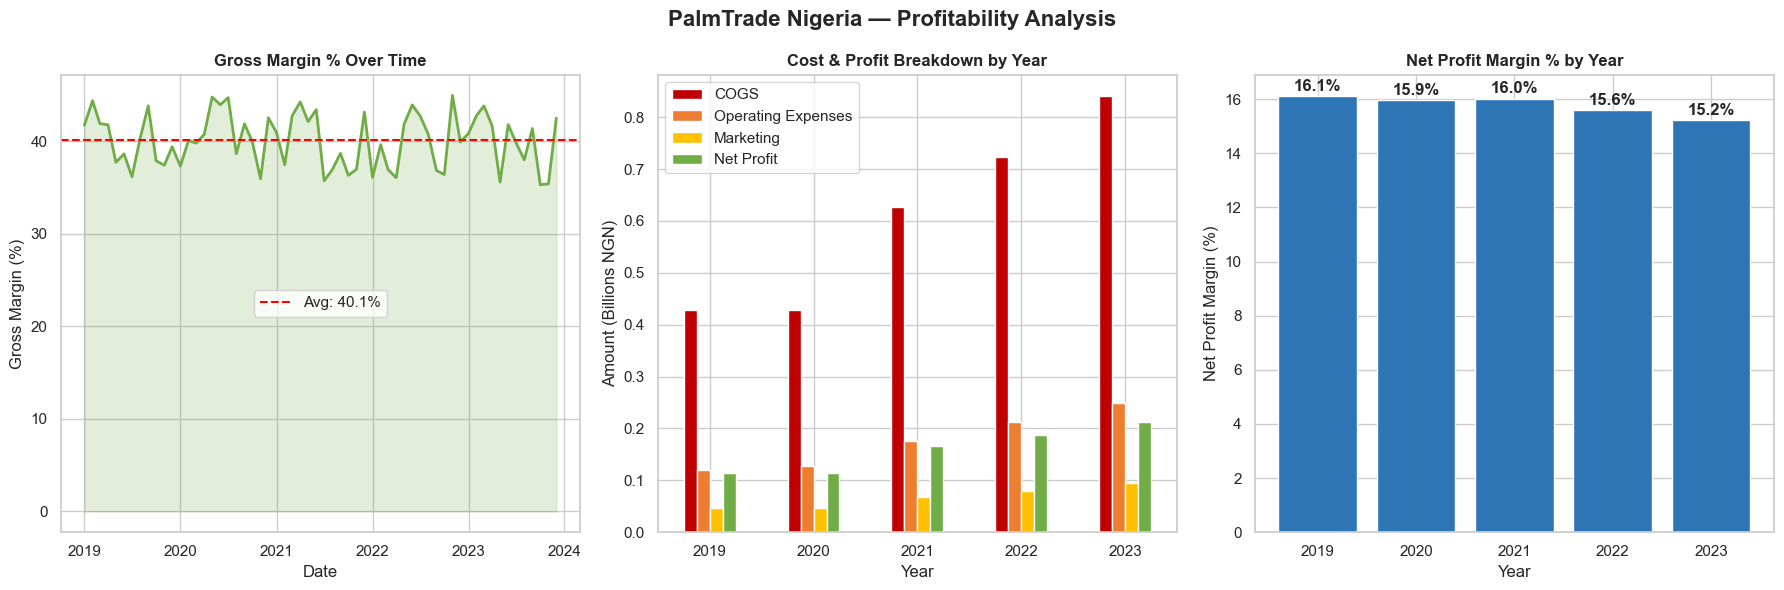

In [5]:
# Section 5 - Profitability Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 - Gross Margin Trend
monthly_margin = df.groupby('Date')['Gross_Margin_Pct'].mean().reset_index()
axes[0].plot(monthly_margin['Date'], monthly_margin['Gross_Margin_Pct'],
             color='#70AD47', linewidth=2)
axes[0].fill_between(monthly_margin['Date'], monthly_margin['Gross_Margin_Pct'],
                      alpha=0.2, color='#70AD47')
axes[0].set_title('Gross Margin % Over Time', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Gross Margin (%)')
axes[0].axhline(y=monthly_margin['Gross_Margin_Pct'].mean(), 
                color='red', linestyle='--', label=f"Avg: {monthly_margin['Gross_Margin_Pct'].mean():.1f}%")
axes[0].legend()

# Chart 2 - Cost Breakdown by Year
cost_data = df.groupby('Year')[['COGS_NGN', 'Operating_Expenses_NGN', 
                                  'Marketing_Spend_NGN', 'Net_Profit_NGN']].sum()
cost_data_B = cost_data / 1_000_000_000
cost_data_B.plot(kind='bar', ax=axes[1], 
                  color=['#C00000', '#ED7D31', '#FFC000', '#70AD47'])
axes[1].set_title('Cost & Profit Breakdown by Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Amount (Billions NGN)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['COGS', 'Operating Expenses', 'Marketing', 'Net Profit'])

# Chart 3 - Revenue vs Cost Efficiency
efficiency = df.groupby('Year').agg(
    Revenue=('Revenue_NGN', 'sum'),
    Total_Cost=('COGS_NGN', 'sum'),
    Net_Profit=('Net_Profit_NGN', 'sum')
).reset_index()
efficiency['Profit_Margin_Pct'] = (efficiency['Net_Profit'] / efficiency['Revenue'] * 100).round(2)
axes[2].bar(efficiency['Year'], efficiency['Profit_Margin_Pct'], color='#2E75B6')
axes[2].set_title('Net Profit Margin % by Year', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Net Profit Margin (%)')
for i, v in enumerate(efficiency['Profit_Margin_Pct']):
    axes[2].text(efficiency['Year'].iloc[i], v+0.2, f'{v:.1f}%',
                 ha='center', fontweight='bold')

plt.suptitle('PalmTrade Nigeria — Profitability Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_profitability.png', dpi=150, bbox_inches='tight')
plt.show()

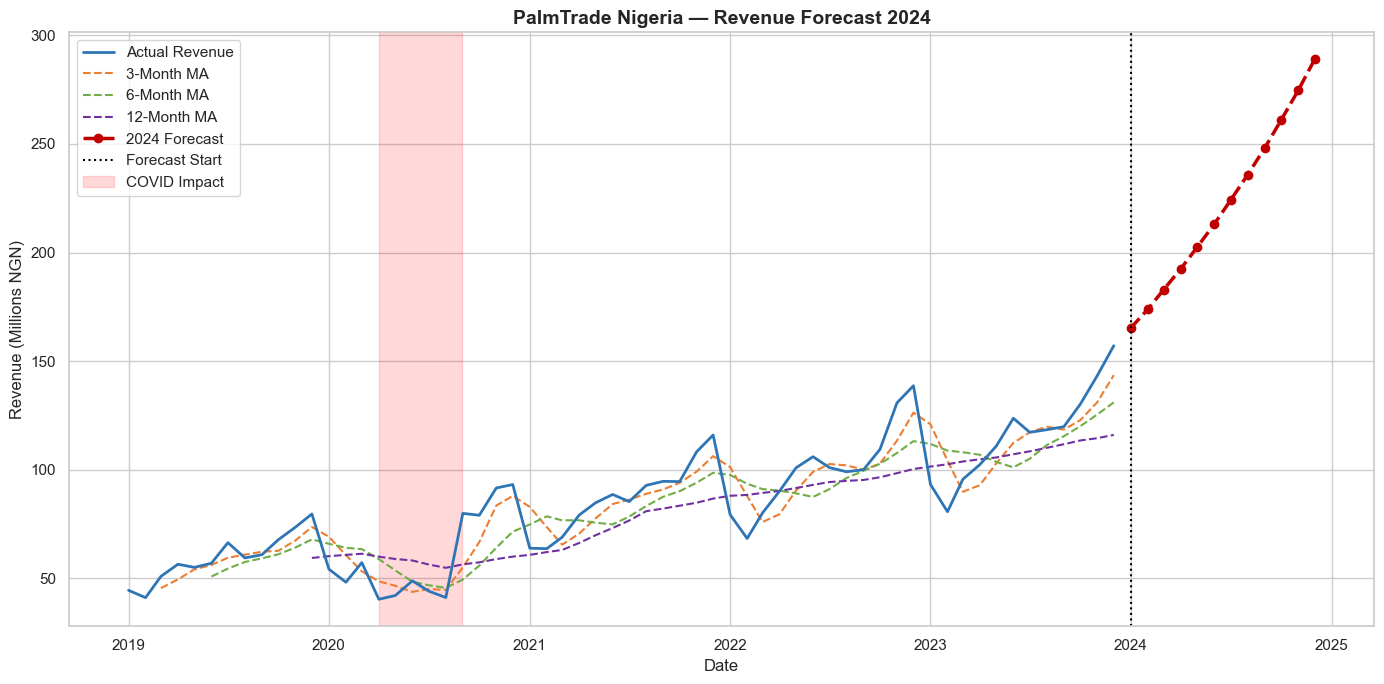


2024 Revenue Forecast (Moving Average Method):
----------------------------------------
Jan 2024: NGN 165,318,140
Feb 2024: NGN 173,928,147
Mar 2024: NGN 182,986,576
Apr 2024: NGN 192,516,782
May 2024: NGN 202,543,334
Jun 2024: NGN 213,092,083
Jul 2024: NGN 224,190,226
Aug 2024: NGN 235,866,377
Sep 2024: NGN 248,150,639
Oct 2024: NGN 261,074,682
Nov 2024: NGN 274,671,829
Dec 2024: NGN 288,977,135

Total Forecast 2024: NGN 2,663,315,950


In [6]:
# Section 6 - Revenue Forecasting

# Aggregate monthly revenue across all regions
monthly_total = df.groupby('Date')['Revenue_NGN'].sum().reset_index()
monthly_total = monthly_total.sort_values('Date')
monthly_total['Revenue_M'] = monthly_total['Revenue_NGN'] / 1_000_000

# Calculate Moving Averages
monthly_total['MA_3'] = monthly_total['Revenue_M'].rolling(window=3).mean()
monthly_total['MA_6'] = monthly_total['Revenue_M'].rolling(window=6).mean()
monthly_total['MA_12'] = monthly_total['Revenue_M'].rolling(window=12).mean()

# Simple forecast: extend trend using last 12 months average growth
last_12 = monthly_total.tail(12)
avg_growth = last_12['Revenue_M'].pct_change().mean()

last_value = monthly_total['Revenue_M'].iloc[-1]
forecast_dates = pd.date_range(start='2024-01-01', periods=12, freq='MS')
forecast_values = [last_value * (1 + avg_growth) ** i for i in range(1, 13)]

# Plot
plt.figure(figsize=(14, 7))
plt.plot(monthly_total['Date'], monthly_total['Revenue_M'],
         color='#2E75B6', linewidth=2, label='Actual Revenue', zorder=3)
plt.plot(monthly_total['Date'], monthly_total['MA_3'],
         color='#ED7D31', linewidth=1.5, linestyle='--', label='3-Month MA')
plt.plot(monthly_total['Date'], monthly_total['MA_6'],
         color='#70AD47', linewidth=1.5, linestyle='--', label='6-Month MA')
plt.plot(monthly_total['Date'], monthly_total['MA_12'],
         color='#7030A0', linewidth=1.5, linestyle='--', label='12-Month MA')
plt.plot(forecast_dates, forecast_values,
         color='#C00000', linewidth=2.5, linestyle='--',
         marker='o', markersize=6, label='2024 Forecast')
plt.axvline(x=pd.Timestamp('2024-01-01'), color='black',
            linestyle=':', linewidth=1.5, label='Forecast Start')
plt.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2020-08-31'),
            alpha=0.15, color='red', label='COVID Impact')

plt.title('PalmTrade Nigeria — Revenue Forecast 2024',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (Millions NGN)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('chart3_revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n2024 Revenue Forecast (Moving Average Method):")
print("-" * 40)
for date, value in zip(forecast_dates, forecast_values):
    print(f"{date.strftime('%b %Y')}: NGN {value*1_000_000:,.0f}")
print(f"\nTotal Forecast 2024: NGN {sum(forecast_values)*1_000_000:,.0f}")

In [7]:
# Section 7 - Final Summary

print("=" * 58)
print("   PALMTRADE NIGERIA — COMPLETE FINANCIAL SUMMARY")
print("=" * 58)

total_rev = df['Revenue_NGN'].sum()
total_profit = df['Net_Profit_NGN'].sum()
total_cogs = df['COGS_NGN'].sum()
total_opex = df['Operating_Expenses_NGN'].sum()
total_marketing = df['Marketing_Spend_NGN'].sum()
avg_margin = df['Gross_Margin_Pct'].mean()
profit_margin = (total_profit / total_rev) * 100
best_region = df.groupby('Region')['Revenue_NGN'].sum().idxmax()
best_quarter = df.groupby('Quarter')['Revenue_NGN'].sum().idxmax()

print(f"""
5-YEAR TOTALS (2019-2023)
------------------------------
Total Revenue:        NGN {total_rev:,.0f}
Total COGS:           NGN {total_cogs:,.0f}
Total Operating Exp:  NGN {total_opex:,.0f}
Total Marketing:      NGN {total_marketing:,.0f}
Total Net Profit:     NGN {total_profit:,.0f}

KEY RATIOS
------------------------------
Avg Gross Margin:     {avg_margin:.1f}%
Net Profit Margin:    {profit_margin:.1f}%
COGS as % Revenue:    {total_cogs/total_rev*100:.1f}%

TOP PERFORMERS
------------------------------
Best Region:          {best_region}
Best Quarter:         {best_quarter} (festive season effect)
Best Year:            2023 (post-COVID recovery)

2024 FORECAST
------------------------------
Method:               12-Month Moving Average Trend
Expected Growth:      Based on 2023 momentum
Risk Factor:          External economic pressures

KEY RECOMMENDATIONS
------------------------------
1. Invest more in Lagos — consistently highest revenue region
2. Boost Q1 and Q2 campaigns to reduce seasonal revenue dips
3. Monitor COGS closely — currently 55-65% of revenue
4. Replicate Q4 festive season strategies in Q2 and Q3
5. Target 15%+ net profit margin through cost optimisation
""")
print("=" * 58)
print("   ANALYSIS COMPLETE - READY FOR POWER BI")
print("=" * 58)

   PALMTRADE NIGERIA — COMPLETE FINANCIAL SUMMARY

5-YEAR TOTALS (2019-2023)
------------------------------
Total Revenue:        NGN 5,071,495,811
Total COGS:           NGN 3,047,319,670
Total Operating Exp:  NGN 886,763,920
Total Marketing:      NGN 336,485,214
Total Net Profit:     NGN 796,188,555

KEY RATIOS
------------------------------
Avg Gross Margin:     40.1%
Net Profit Margin:    15.7%
COGS as % Revenue:    60.1%

TOP PERFORMERS
------------------------------
Best Region:          Lagos
Best Quarter:         Q4 (festive season effect)
Best Year:            2023 (post-COVID recovery)

2024 FORECAST
------------------------------
Method:               12-Month Moving Average Trend
Expected Growth:      Based on 2023 momentum
Risk Factor:          External economic pressures

KEY RECOMMENDATIONS
------------------------------
1. Invest more in Lagos — consistently highest revenue region
2. Boost Q1 and Q2 campaigns to reduce seasonal revenue dips
3. Monitor COGS closely — curr

In [8]:
# Section 8 - Export for Power BI

# Export main dataset
df.to_csv('palmtrade_financial_clean.csv', index=False)

# Export monthly totals (for trend charts)
monthly_summary = df.groupby(['Date', 'Year', 'Month', 'Month_Name', 'Quarter']).agg(
    Revenue_NGN=('Revenue_NGN', 'sum'),
    Net_Profit_NGN=('Net_Profit_NGN', 'sum'),
    Gross_Profit_NGN=('Gross_Profit_NGN', 'sum'),
    COGS_NGN=('COGS_NGN', 'sum'),
    Units_Sold=('Units_Sold', 'sum'),
    Gross_Margin_Pct=('Gross_Margin_Pct', 'mean')
).reset_index()
monthly_summary.to_csv('palmtrade_monthly_summary.csv', index=False)

print("Exported successfully ✅")
print(f"Main dataset: {df.shape}")
print(f"Monthly summary: {monthly_summary.shape}")

Exported successfully ✅
Main dataset: (300, 14)
Monthly summary: (60, 11)
